In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Split
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LogisticRegression

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve)

# Cargar dataset procesado
credit_df = pd.read_csv("../data/processed/credit_df_processed.csv")
credit_df.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Not Graduate,self_employed_ Yes
0,-0.294102,1.617979,1.633052,0.192617,1.032792,-0.780249,2.877289,0.832028,0.930304,1,0,0
1,-1.473548,-0.341750,-0.324414,-0.508091,-1.061051,-0.734111,-0.631921,-0.694993,-0.515936,0,1,1
2,0.295621,1.439822,1.610933,1.594031,-0.544840,-0.057408,-0.107818,1.996520,2.407316,0,0,0
3,0.295621,1.119139,1.721525,-0.508091,-0.771045,1.649729,-0.381263,0.897943,0.899533,0,0,0
4,1.475067,1.689242,1.002681,1.594031,-1.264055,0.757711,0.735304,1.568075,0.007172,0,1,1


# Dividir los datos
1. Datos de entrenamiento
2. Datos para aprobar el model



In [2]:
# Se separan las variables predictoras (X) y la variable objetivo (y) para el entrenamiento del modelo.
# Variables predictoras
X = credit_df.drop(columns=['loan_status'])

# Variable objetivo
y = credit_df['loan_status']

In [3]:
X

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes
0,-0.294102,1.617979,1.633052,0.192617,1.032792,-0.780249,2.877289,0.832028,0.930304,0,0
1,-1.473548,-0.341750,-0.324414,-0.508091,-1.061051,-0.734111,-0.631921,-0.694993,-0.515936,1,1
2,0.295621,1.439822,1.610933,1.594031,-0.544840,-0.057408,-0.107818,1.996520,2.407316,0,0
3,0.295621,1.119139,1.721525,-0.508091,-0.771045,1.649729,-0.381263,0.897943,0.899533,0,0
4,1.475067,1.689242,1.002681,1.594031,-1.264055,0.757711,0.735304,1.568075,0.007172,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4264,1.475067,-1.446324,-1.419268,0.192617,-1.641063,-0.718731,-1.019301,-1.299210,-1.285213,0,1
4265,-1.473548,-0.626801,-0.423946,1.594031,-0.237434,-0.503416,-0.472412,-0.453306,-0.946732,1,1
4266,-0.294102,0.513405,0.969504,1.243677,-0.829046,-0.964805,1.692361,0.326683,0.714907,1,0
4267,-0.883825,-0.341750,-0.258059,-0.508091,1.044393,0.111768,-0.973727,-0.112748,0.253341,1,0


In [4]:
y

0       1
1       0
2       0
3       0
4       0
       ..
4264    0
4265    1
4266    0
4267    1
4268    1
Name: loan_status, Length: 4269, dtype: int64

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42)
#Se realiza una división estratificada para preservar la distribución de la variable objetivo.


In [6]:
# vemos el tamaño de los datos
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3415, 11), (854, 11), (3415,), (854,))

In [7]:
# pasamos a la modelacion usando regresion logistica

log_reg = LogisticRegression(max_iter = 1000, random_state = 42, n_jobs= -1)

log_reg.fit(X_train, y_train)

#Se entrena un modelo de Regresión Logística como baseline por su interpretabilidad en contextos de riesgo crediticio.

LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)

In [8]:
# Predicciones y probabilidades 

y_pred_lr = log_reg.predict(X_test)  #clases
y_prob_lr = log_reg.predict_proba(X_test)[:, 1] #probabilidad de aprobación


In [9]:
y_pred_lr

array([0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,

In [10]:
y_prob_lr

array([3.29713545e-02, 8.43431329e-01, 2.50093526e-02, 9.61791025e-01,
       9.89155472e-01, 9.78473684e-01, 9.89051422e-01, 3.76435507e-01,
       7.58478784e-01, 2.20847796e-01, 6.20044499e-01, 9.93146634e-01,
       9.89367677e-01, 6.41586118e-02, 3.61608637e-02, 9.67181955e-01,
       9.80683106e-01, 7.32557271e-01, 3.09719787e-02, 6.94783564e-02,
       7.83550978e-01, 1.67477933e-02, 1.18661294e-01, 9.00607525e-02,
       9.97101868e-01, 9.78698183e-01, 9.99223395e-01, 7.43322621e-01,
       9.98308829e-01, 1.26728937e-01, 8.97617392e-01, 3.14755061e-02,
       7.01543424e-01, 8.42997487e-01, 2.46774706e-03, 4.05153267e-02,
       8.82885258e-01, 8.91357684e-01, 9.99775492e-01, 1.05625953e-02,
       3.79655114e-01, 8.96995264e-01, 9.99826308e-01, 9.99907989e-01,
       3.25044041e-01, 9.61709448e-01, 9.99374046e-01, 9.70261753e-01,
       9.99776139e-01, 4.20663787e-02, 9.95581789e-01, 4.67157362e-01,
       4.46293804e-01, 9.99743557e-01, 9.92320858e-01, 9.93284509e-01,
      

In [12]:
#Evaluacion del modelo
print("\nEvaluacion para el Modelo de Regresion Logistica")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}") #:.4f solo 4 numeros decimales
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"Roc-AUC: {roc_auc_score(y_test, y_pred_lr):.4f}")


Evaluacion para el Modelo de Regresion Logistica
Accuracy: 0.9052
Precision: 0.9205
Recall: 0.9291
F1-Score: 0.9248
Roc-AUC: 0.8969


- 0.03 → cliente con 97% probabilidad de rechazo
- 0.84 → cliente muy probable aprobado
- 0.55 → cliente zona gris
- 0.99 → cliente excelente perfil crediticio

In [13]:
#Evaluacion del modelo
print("\nEvaluacion para el Modelo de Regresion Logistica")
print(f"Roc-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}") #Eso te va a dar el AUC real del modelo.


Evaluacion para el Modelo de Regresion Logistica
Roc-AUC: 0.9675


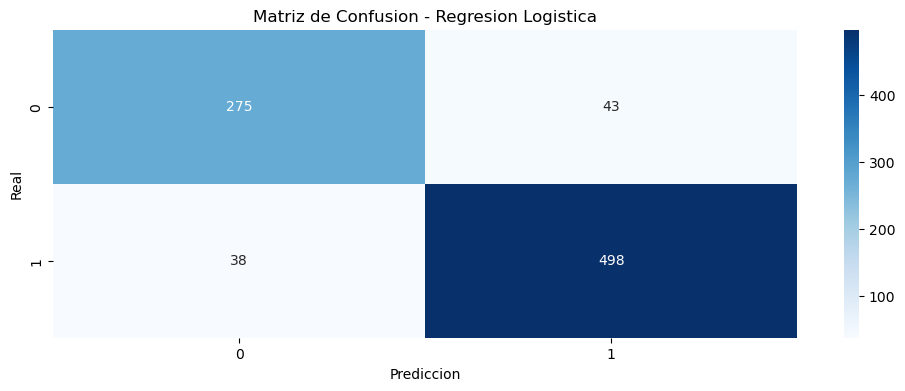

In [14]:
# Matriz de Confusion

conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize = (12, 4))
sns.heatmap(conf_matrix_lr, annot= True, fmt = 'd', cmap= 'Blues')
plt.title("Matriz de Confusion - Regresion Logistica")
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()

La matriz de confusión indica que el modelo presenta un desempeño sólido y consistente. Se observa una alta capacidad para identificar correctamente tanto créditos aprobados (498 casos) como rechazados (275 casos).

Es especialmente relevante la baja cantidad de falsos positivos (43), ya que en el contexto de riesgo crediticio este tipo de error representa una pérdida financiera directa.

Asimismo, los falsos negativos (38) reflejan oportunidades de negocio perdidas, un trade-off aceptable en escenarios donde se prioriza la reducción del riesgo. En conjunto, el modelo demuestra un buen equilibrio entre rentabilidad y control de riesgo.

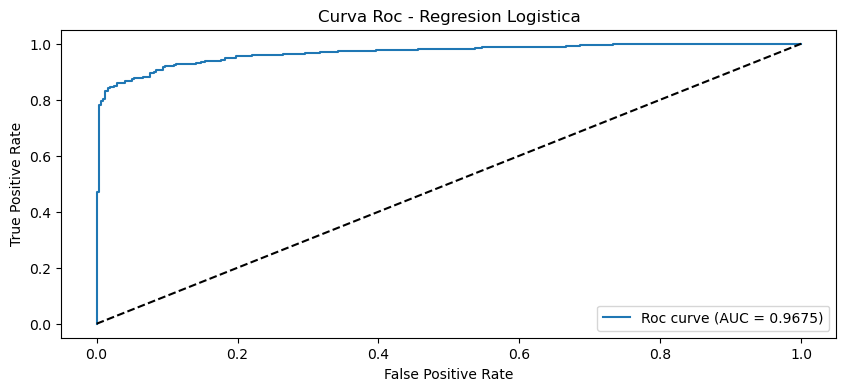

In [19]:

# curva Roc
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.figure(figsize=(10,4))
plt.plot(fpr, tpr, label = f'Roc curve (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.title("Curva Roc - Regresion Logistica")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

La curva ROC muestra una excelente capacidad de discriminación del modelo, con un AUC de 0.9675. Esto indica que el modelo separa de manera efectiva a los clientes aprobados de los rechazados, manteniendo una alta tasa de verdaderos positivos incluso con bajos niveles de falsos positivos. Este comportamiento permite ajustar el umbral de decisión según la política de riesgo sin perder robustez predictiva.

**ROC-AUC de 0.9675**

Si tomamos al azar un cliente bueno y uno malo, el modelo tiene un 96.75% de probabilidad de asignarle una mayor probabilidad de aprobación al cliente bueno.

In [20]:
import pickle

with open("../models/logistic_regression.pkl", "wb") as f:
    pickle.dump(log_reg, f)